# Smoke Detection in Remote Sensing Imagery

CBS 8th Semester — Machine Learning and Deep Learning Exam

In [4]:
%pip install -q "numpy==1.26.4" pandas matplotlib scikit-learn scikit-image opencv-python pillow tifffile "tensorflow==2.10.0" "keras==2.10.0" imagehash seaborn
%pip install -q datasets

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


#### Importing Libraries

In [5]:
import os
import random
import time
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import tifffile
import seaborn as sns
import joblib
from PIL import Image, ImageEnhance
from datasets import load_dataset
from collections import Counter
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import imagehash
import tensorflow as tf
from tensorflow.keras.applications import ResNet50

In [6]:
! python --version

Python 3.10.11


### USTC_SmokeRS dataset

In [7]:
ustc = load_dataset("jonathan-roberts1/USTC_SmokeRS", split="train")

print(f"Total images : {len(ustc)}")
print(f"Features     : {ustc.features}")
print(f"Classes      : {ustc.features['label'].names}")

Total images : 6225
Features     : {'image': Image(mode=None, decode=True), 'label': ClassLabel(names=['cloud', 'dust', 'haze', 'land', 'seaside', 'smoke'])}
Classes      : ['cloud', 'dust', 'haze', 'land', 'seaside', 'smoke']


In [8]:
class_names = ustc.features["label"].names
counts = Counter(ustc["label"])

print("Class distribution:")
for idx, name in enumerate(class_names):
    print(f"  {name:<10} : {counts[idx]}")

Class distribution:
  cloud      : 1164
  dust       : 1009
  haze       : 1002
  land       : 1027
  seaside    : 1007
  smoke      : 1016


In [9]:
sample = np.array(ustc[0]["image"])
print(f"dtype  : {sample.dtype}")
print(f"shape  : {sample.shape}  (H × W × C)")

sizes = [np.array(row["image"]).shape[:2] for row in ustc.select(range(50))]
unique_sizes = set(sizes)
print(f"Unique sizes in first 50 samples: {unique_sizes}")

dtype  : uint8
shape  : (256, 256, 3)  (H × W × C)
Unique sizes in first 50 samples: {(256, 256)}


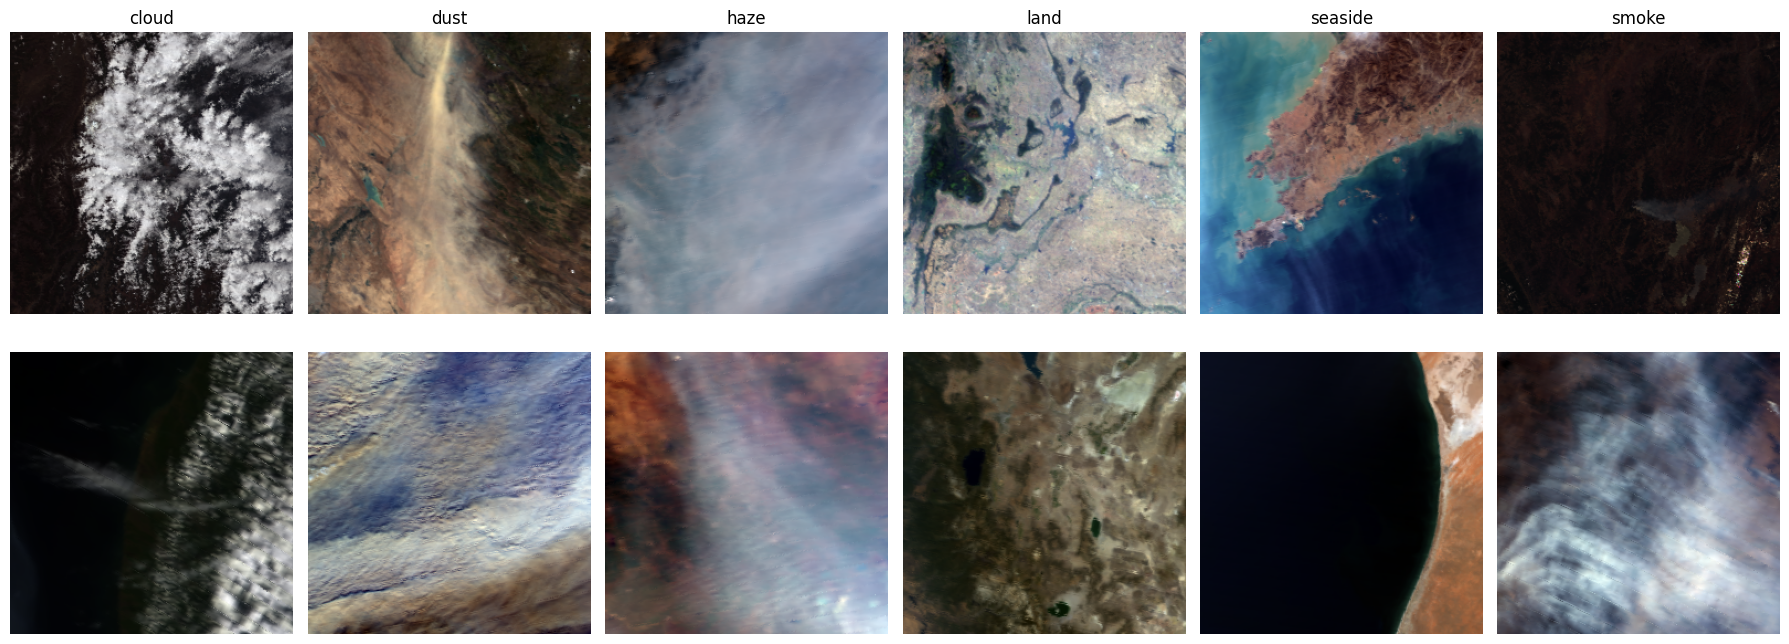

In [10]:
# ! REMOVE THE COMMENT THING

fig, axes = plt.subplots(2, 6, figsize=(18, 7))

for col, class_name in enumerate(class_names):
    idx = class_names.index(class_name)
    samples = [row for row in ustc if row["label"] == idx][:2]
    for row_i, s in enumerate(samples):
        axes[row_i][col].imshow(s["image"])
        axes[row_i][col].set_title(class_name if row_i == 0 else "")
        axes[row_i][col].axis("off")

plt.tight_layout()
plt.show()

### Data Preprocessing

In [11]:
TARGET_SIZE = (224, 224)

def load_ustc(pil_image):
    img = pil_image.resize(TARGET_SIZE, Image.BILINEAR)
    return np.array(img)

# verify
sample = load_ustc(ustc[0]["image"])
print(f"USTC loaded shape: {sample.shape}")

USTC loaded shape: (224, 224, 3)


In [12]:
pool = pd.DataFrame([
    {"index": i, "label": row["label"], "class": class_names[row["label"]]}
    for i, row in enumerate(ustc)
])

print(pool.groupby("class")["label"].count().rename("count"))
print(f"\nTotal: {len(pool)}")

pool.head()

class
cloud      1164
dust       1009
haze       1002
land       1027
seaside    1007
smoke      1016
Name: count, dtype: int64

Total: 6225


,index,label,class
0,0,0,cloud
1,1,0,cloud
2,2,0,cloud
3,3,0,cloud
4,4,0,cloud


In [13]:
train_val, test = train_test_split(pool, test_size=0.20, stratify=pool["label"], random_state=42)
train, val      = train_test_split(train_val, test_size=0.25, stratify=train_val["label"], random_state=42)

print(f"Train : {len(train)}  Val : {len(val)}  Test : {len(test)}")

Train : 3735  Val : 1245  Test : 1245


In [14]:
splits = {"train": train, "val": val, "test": test}

rows = []
for name in class_names:
    row = {"class": name}
    for split_name, df in splits.items():
        row[split_name] = (df["class"] == name).sum()
    rows.append(row)

df_split = pd.DataFrame(rows).set_index("class")
df_split["total"] = df_split.sum(axis=1)
for col in ["train", "val", "test"]:
    df_split[f"{col}%"] = (df_split[col] / df_split["total"] * 100).round(1)

df_split[["train", "val", "test", "train%", "val%", "test%"]]

,train,val,test,train%,val%,test%
class,,,,,,
cloud,698,233,233,60.0,20.0,20.0
dust,605,202,202,60.0,20.0,20.0
haze,602,200,200,60.1,20.0,20.0
land,616,206,205,60.0,20.1,20.0
seaside,604,201,202,60.0,20.0,20.1
smoke,610,203,203,60.0,20.0,20.0


### EDA (Training Set)

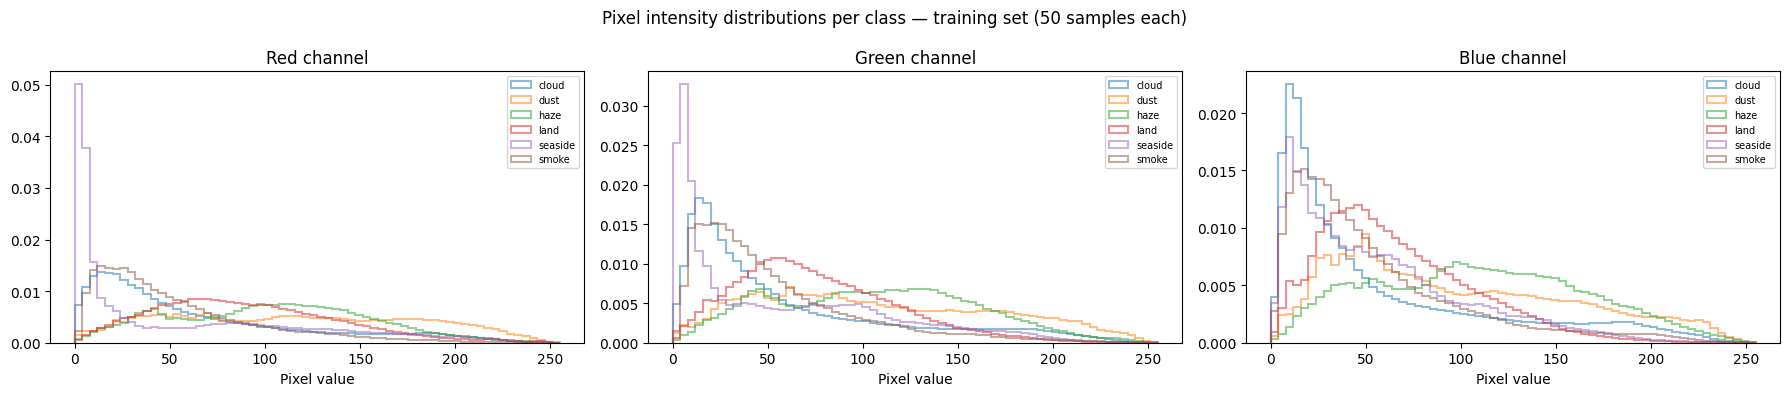

In [15]:
N_SAMPLE = 50
channel_labels = ["Red", "Green", "Blue"]
class_colors = plt.cm.tab10.colors

samples_per_class = {
    name: [ustc[i] for i in train[train["class"] == name]["index"].tolist()[:N_SAMPLE]]
    for name in class_names
}

def sample_pixels_ustc(rows):
    pixels = [[], [], []]
    for row in rows:
        img = np.array(row["image"])
        for c in range(3):
            pixels[c].append(img[:, :, c].flatten())
    return [np.concatenate(ch) for ch in pixels]

class_pixels = {name: sample_pixels_ustc(samples_per_class[name]) for name in class_names}

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for c, ax in enumerate(axes):
    for i, name in enumerate(class_names):
        ax.hist(class_pixels[name][c], bins=64, range=(0, 255), alpha=0.5,
                color=class_colors[i], label=name, density=True, histtype="step", linewidth=1.5)
    ax.set_title(f"{channel_labels[c]} channel")
    ax.set_xlabel("Pixel value")
    ax.legend(fontsize=7)

plt.suptitle("Pixel intensity distributions per class — training set (50 samples each)")
plt.tight_layout()
plt.show()

In [16]:
for name in class_names:
    px = class_pixels[name]
    for c, ch in enumerate(channel_labels):
        print(f"{name:<10} {ch:6}: mean={px[c].mean():.1f}  std={px[c].std():.1f}")

cloud      Red   : mean=64.5  std=56.8
cloud      Green : mean=61.9  std=57.4
cloud      Blue  : mean=59.5  std=58.5
dust       Red   : mean=115.3  std=63.2
dust       Green : mean=107.7  std=61.4
dust       Blue  : mean=98.1  std=60.8
haze       Red   : mean=103.0  std=51.2
haze       Green : mean=106.1  std=52.5
haze       Blue  : mean=109.9  std=54.8
land       Red   : mean=90.3  std=47.7
land       Green : mean=75.9  std=41.3
land       Blue  : mean=66.6  std=39.3
seaside    Red   : mean=55.5  std=61.8
seaside    Green : mean=56.4  std=54.5
seaside    Blue  : mean=57.3  std=45.5
smoke      Red   : mean=53.2  std=42.4
smoke      Green : mean=53.4  std=43.1
smoke      Blue  : mean=55.2  std=46.3


In [17]:
rows_eda = []
for name in class_names:
    for row in samples_per_class[name]:
        img = np.array(row["image"]).astype(np.float64)
        rows_eda.append({"class": name, "mean": img.mean(), "std": img.std()})

df_eda = pd.DataFrame(rows_eda)
df_eda.groupby("class")[["mean", "std"]].mean().round(1).rename(columns={"mean": "avg brightness"})

,avg brightness,std
class,,
cloud,62.0,47.2
dust,107.0,41.7
haze,106.3,37.6
land,77.6,35.9
seaside,56.4,47.2
smoke,53.9,32.6


### Data Filtering

#### Checking for duplicates

In [18]:
def ahash(pil_image, hash_size=12):
    img = pil_image.convert("L").resize((hash_size, hash_size), Image.BILINEAR)
    arr = np.array(img, dtype=np.float32)
    return int(np.packbits((arr > arr.mean()).flatten()).tobytes().hex(), 16)

seen = {}
duplicate_indices = []
for i in pool["index"]:
    h = ahash(ustc[i]["image"])
    if h in seen:
        duplicate_indices.append(i)
    else:
        seen[h] = i

print(f"Images checked   : {len(pool)}")
print(f"Duplicates found : {len(duplicate_indices)}")
if duplicate_indices:
    print(f"Flagged indices  : {duplicate_indices}")

KeyboardInterrupt: 

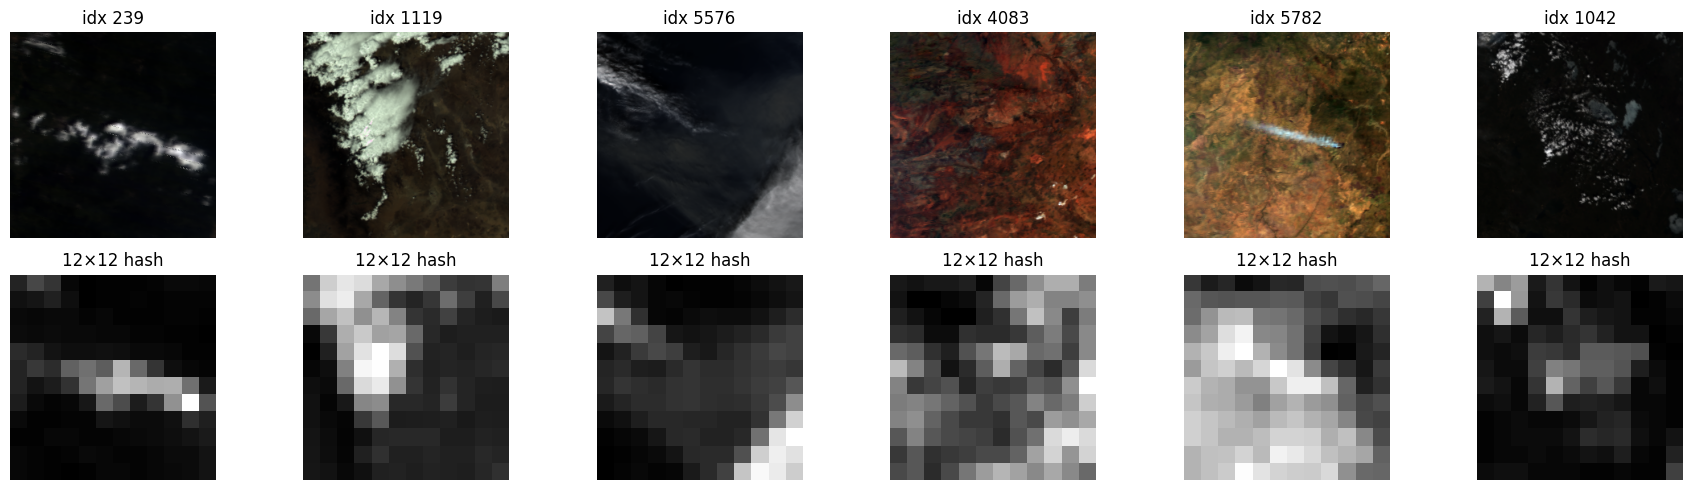

In [ ]:
# THIS WAS MADE TO HELP US UNDERSTAND HOW THE HASHING ACTUALLY WORK 

n_show = 6
sample_indices = pool["index"].sample(n_show, random_state=42).tolist()

fig, axes = plt.subplots(2, n_show, figsize=(18, 5))
for col, idx in enumerate(sample_indices):
    img_orig = ustc[idx]["image"]
    img_small = img_orig.convert("L").resize((12, 12), Image.BILINEAR)

    axes[0][col].imshow(img_orig)
    axes[0][col].set_title(f"idx {idx}")
    axes[0][col].axis("off")

    axes[1][col].imshow(img_small, cmap="gray", interpolation="nearest")
    axes[1][col].set_title("12×12 hash")
    axes[1][col].axis("off")

plt.tight_layout()
plt.show()

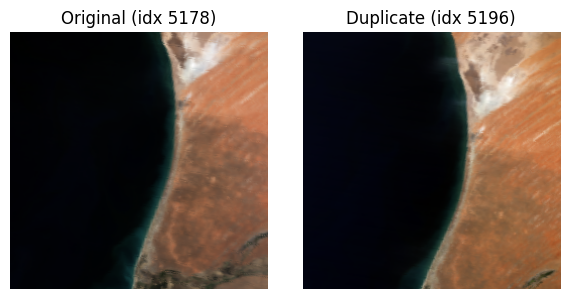

In [ ]:
if duplicate_indices:
    fig, axes = plt.subplots(len(duplicate_indices), 2, figsize=(6, 3 * len(duplicate_indices)))
    if len(duplicate_indices) == 1:
        axes = [axes]
    for ax_row, dup_idx in zip(axes, duplicate_indices):
        orig_idx = seen[ahash(ustc[dup_idx]["image"])]
        ax_row[0].imshow(ustc[orig_idx]["image"])
        ax_row[0].set_title(f"Original (idx {orig_idx})")
        ax_row[0].axis("off")
        ax_row[1].imshow(ustc[dup_idx]["image"])
        ax_row[1].set_title(f"Duplicate (idx {dup_idx})")
        ax_row[1].axis("off")
    plt.tight_layout()
    plt.show()
else:
    print("No duplicates to display.")


In [ ]:
# ANOTHER WAY TO CHECK FOR DUPLICATES

seen_ph = {}
duplicate_indices_ph = []
for i in pool["index"]:
    h = imagehash.phash(ustc[i]["image"])
    if h in seen_ph:
        duplicate_indices_ph.append(i)
    else:
        seen_ph[h] = i

print(f"Images checked   : {len(pool)}")
print(f"Duplicates found : {len(duplicate_indices_ph)}")
if duplicate_indices_ph:
    for dup_idx in duplicate_indices_ph:
        orig_idx = seen_ph[imagehash.phash(ustc[dup_idx]["image"])]
        print(f"  Flagged idx {dup_idx} matches idx {orig_idx}")

Images checked   : 6225
Duplicates found : 0


#### Check for currput or unreadable images

In [ ]:
corrupt_indices = []
for i in pool["index"]:
    try:
        img = np.array(ustc[i]["image"])
        assert img.ndim == 3 and img.shape[2] == 3
    except Exception:
        corrupt_indices.append(i)

print(f"Images checked  : {len(pool)}")
print(f"Corrupt found   : {len(corrupt_indices)}")
if corrupt_indices:
    print(f"Flagged indices : {corrupt_indices}")

Images checked  : 6225
Corrupt found   : 0


#### RGB anomalies

In [ ]:
anomaly_indices = []
for i in pool["index"]:
    avg = np.array(ustc[i]["image"]).mean()
    if avg < 5 or avg > 250:
        anomaly_indices.append(i)

print(f"Images checked  : {len(pool)}")
print(f"Anomalies found : {len(anomaly_indices)}")
if anomaly_indices:
    print(f"Flagged indices : {anomaly_indices}")

Images checked  : 6225
Anomalies found : 0


### Data Normalisation

In [ ]:
def normalise(img):
    return img.astype(np.float32) / 255.0

# verify
sample = load_ustc(ustc[0]["image"])
print(f"Before: min={sample.min()}  max={sample.max()}  dtype={sample.dtype}")
norm = normalise(sample)
print(f"After : min={norm.min():.1f}  max={norm.max():.1f}  dtype={norm.dtype}")

Before: min=6  max=245  dtype=uint8
After : min=0.0  max=1.0  dtype=float32


In [ ]:
IMAGENET_MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32)
IMAGENET_STD  = np.array([0.229, 0.224, 0.225], dtype=np.float32)

def normalise_imagenet(img):
    return (img.astype(np.float32) / 255.0 - IMAGENET_MEAN) / IMAGENET_STD

# verify
norm_in = normalise_imagenet(sample)
print(f"Shape : {norm_in.shape}")
print(f"Mean  : {norm_in.mean(axis=(0,1)).round(3)}  (expect near 0)")
print(f"Std   : {norm_in.std(axis=(0,1)).round(3)}   (expect near 1)")

Shape : (224, 224, 3)
Mean  : [-0.658 -0.6   -0.346]  (expect near 0)
Std   : [1.118 1.175 1.18 ]   (expect near 1)


In [ ]:
def load_split(df, normalise_fn):
    X = np.stack([normalise_fn(load_ustc(ustc[i]["image"])) for i in df["index"]])
    y = df["label"].values
    return X, y

# verify on a small sample
sample_df = train.sample(5, random_state=0)
X_sample, y_sample = load_split(sample_df, normalise)
print(f"Shape : {X_sample.shape}  dtype: {X_sample.dtype}")
print(f"Range : [{X_sample.min():.2f}, {X_sample.max():.2f}]")
print(f"Labels: {y_sample}")

Shape : (5, 224, 224, 3)  dtype: float32
Range : [0.00, 0.99]
Labels: [4 0 4 5 5]


### Data Augmentation (training set only)

In [ ]:
def aug_flip(img):
    return img.transpose(Image.FLIP_LEFT_RIGHT)

def aug_rotate(img):
    return img.rotate(random.choice([90, 180, 270]))

def aug_brightness(img):
    return ImageEnhance.Brightness(img).enhance(random.uniform(0.5, 2))

def aug_noise(img):
    arr = np.array(img, dtype=np.float32)
    arr += np.random.normal(0, 10, arr.shape)
    return Image.fromarray(np.clip(arr, 0, 255).astype(np.uint8))

AUG_FUNCS  = [aug_flip, aug_rotate, aug_brightness, aug_noise]
AUG_LABELS = ["flip", "rotate", "brightness", "noise"]

In [ ]:
original = train.assign(aug=0, aug_label="original")
augmented = [train.assign(aug=i+1, aug_label=label) for i, label in enumerate(AUG_LABELS)]

train_aug = pd.concat([original] + augmented, ignore_index=True)

print(f"Before augmentation : {len(train):>5} images")
print(f"After augmentation  : {len(train_aug):>5} images  ({len(train_aug)//len(train)}×)")

Before augmentation :  3735 images
After augmentation  : 18675 images  (5×)


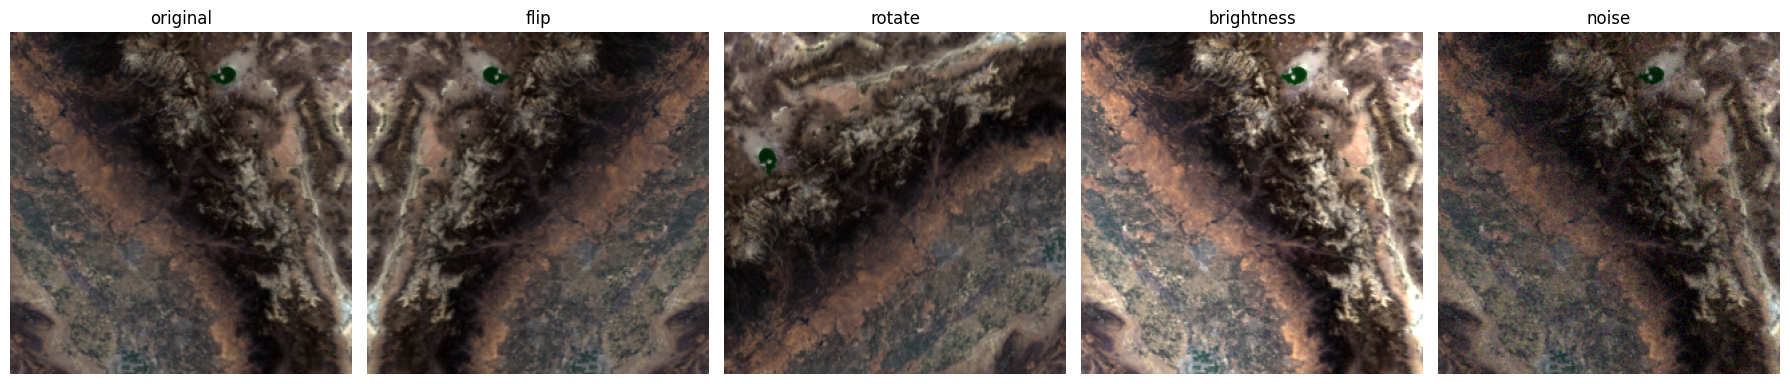

In [ ]:
sample_idx = train["index"].iloc[0]
pil_img = ustc[sample_idx]["image"]

aug_versions = [("original", pil_img)] + [(label, fn(pil_img)) for label, fn in zip(AUG_LABELS, AUG_FUNCS)]

fig, axes = plt.subplots(1, len(aug_versions), figsize=(18, 4))
for ax, (label, img) in zip(axes, aug_versions):
    ax.imshow(img)
    ax.set_title(label)
    ax.axis("off")

plt.tight_layout()
plt.show()

### Data Pipeline

In [ ]:
X_val_norm,      y_val  = load_split(val,  normalise)
X_test_norm,     y_test = load_split(test, normalise)
X_val_imagenet,  _      = load_split(val,  normalise_imagenet)
X_test_imagenet, _      = load_split(test, normalise_imagenet)

print(f"X_val_norm      : {X_val_norm.shape}   [{X_val_norm.min():.2f}, {X_val_norm.max():.2f}]")
print(f"X_test_norm     : {X_test_norm.shape}   [{X_test_norm.min():.2f}, {X_test_norm.max():.2f}]")
print(f"X_val_imagenet  : {X_val_imagenet.shape}")
print(f"X_test_imagenet : {X_test_imagenet.shape}")

X_val_norm      : (1245, 224, 224, 3)   [0.00, 1.00]
X_test_norm     : (1245, 224, 224, 3)   [0.00, 1.00]
X_val_imagenet  : (1245, 224, 224, 3)
X_test_imagenet : (1245, 224, 224, 3)


In [ ]:
X_train_norm,      y_train = load_split(train, normalise)
X_train_imagenet,  _       = load_split(train, normalise_imagenet)

print(f"X_train_norm     : {X_train_norm.shape}   {X_train_norm.nbytes / 1e9:.2f} GB")
print(f"X_train_imagenet : {X_train_imagenet.shape}   {X_train_imagenet.nbytes / 1e9:.2f} GB")

X_train_norm     : (3735, 224, 224, 3)   2.25 GB
X_train_imagenet : (3735, 224, 224, 3)   2.25 GB


In [ ]:
def load_aug_split(df, normalise_fn):
    aug_fns = {1: aug_flip, 2: aug_rotate, 3: aug_brightness, 4: aug_noise}
    X, y = [], []
    for _, row in df.iterrows():
        pil = ustc[row["index"]]["image"]
        if row["aug"] > 0:
            pil = aug_fns[row["aug"]](pil)
        X.append(normalise_fn(load_ustc(pil)))
        y.append(row["label"])
    return np.stack(X), np.array(y)

In [ ]:
print("Pipeline ready")
print(f"  X_train_norm     : {X_train_norm.shape}   (SVM + CNN baseline)")
print(f"  X_train_imagenet : {X_train_imagenet.shape}   (Transfer Learning)")
print(f"  X_val_norm       : {X_val_norm.shape}   y_val:  {y_val.shape}")
print(f"  X_val_imagenet   : {X_val_imagenet.shape}")
print(f"  X_test_norm      : {X_test_norm.shape}   y_test: {y_test.shape}")
print(f"  X_test_imagenet  : {X_test_imagenet.shape}")
print(f"  load_aug_split() : ready — call with (train_aug, normalise) for CNN augmented training")

Pipeline ready
  X_train_norm     : (3735, 224, 224, 3)   (SVM + CNN baseline)
  X_train_imagenet : (3735, 224, 224, 3)   (Transfer Learning)
  X_val_norm       : (1245, 224, 224, 3)   y_val:  (1245,)
  X_val_imagenet   : (1245, 224, 224, 3)
  X_test_norm      : (1245, 224, 224, 3)   y_test: (1245,)
  X_test_imagenet  : (1245, 224, 224, 3)
  load_aug_split() : ready — call with (train_aug, normalise) for CNN augmented training


In [ ]:
'''
The pipeline should produce:

  ┌────────────────────────┬─────────────────┬───────────────┐
  │         Array          │     Used by     │ Normalisation │
  ├────────────────────────┼─────────────────┼───────────────┤
  │ X_train_norm, y_train  │ CNN, SVM        │ [0, 1]        │
  ├────────────────────────┼─────────────────┼───────────────┤
  │ X_train_aug,           │ CNN (augmented) │ [0, 1]        │
  │ y_train_aug            │                 │               │
  ├────────────────────────┼─────────────────┼───────────────┤
  │ X_train_imagenet,      │ Transfer        │ ImageNet      │
  │ y_train                │ Learning        │               │
  ├────────────────────────┼─────────────────┼───────────────┤
  │ X_val_norm, y_val      │ CNN, SVM        │ [0, 1]        │
  ├────────────────────────┼─────────────────┼───────────────┤
  │ X_val_imagenet, y_val  │ Transfer        │ ImageNet      │
  │                        │ Learning        │               │
  ├────────────────────────┼─────────────────┼───────────────┤
  │ X_test_norm, y_test    │ CNN, SVM        │ [0, 1]        │
  ├────────────────────────┼─────────────────┼───────────────┤
  │ X_test_imagenet,       │ Transfer        │ ImageNet      │
  │ y_test                 │ Learning        │               │
  └────────────────────────┴─────────────────┴───────────────┘
'''

'\nThe pipeline should produce:\n\n  ┌────────────────────────┬─────────────────┬───────────────┐\n  │         Array          │     Used by     │ Normalisation │\n  ├────────────────────────┼─────────────────┼───────────────┤\n  │ X_train_norm, y_train  │ CNN, SVM        │ [0, 1]        │\n  ├────────────────────────┼─────────────────┼───────────────┤\n  │ X_train_aug,           │ CNN (augmented) │ [0, 1]        │\n  │ y_train_aug            │                 │               │\n  ├────────────────────────┼─────────────────┼───────────────┤\n  │ X_train_imagenet,      │ Transfer        │ ImageNet      │\n  │ y_train                │ Learning        │               │\n  ├────────────────────────┼─────────────────┼───────────────┤\n  │ X_val_norm, y_val      │ CNN, SVM        │ [0, 1]        │\n  ├────────────────────────┼─────────────────┼───────────────┤\n  │ X_val_imagenet, y_val  │ Transfer        │ ImageNet      │\n  │                        │ Learning        │               │\n  ├──

#### Testing the GPU connection

In [ ]:
import tensorflow as tf                                                                      
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [76]:
#!pip install tensorflow-directml-plugin                                   

### Custom CNN

In [78]:
def augment_batch(x, y):
    x = tf.image.random_flip_left_right(x)
    k = tf.random.uniform(shape=[], minval=0, maxval=4, dtype=tf.int32)
    x = tf.image.rot90(x, k)
    x = tf.image.random_brightness(x, max_delta=0.5)
    x = x + tf.random.normal(shape=tf.shape(x), mean=0.0, stddev=10.0/255.0)
    x = tf.clip_by_value(x, 0.0, 1.0)
    return x, y

In [80]:
def build_cnn(input_shape=(224, 224, 3), num_classes=6):
    inputs = tf.keras.Input(shape=input_shape)

    # Block 1
    x = tf.keras.layers.Conv2D(32, 3, padding='same')(inputs)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.ReLU()(x)
    x = tf.keras.layers.Conv2D(32, 3, padding='same')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.ReLU()(x)
    x = tf.keras.layers.MaxPool2D(2)(x)
    x = tf.keras.layers.Dropout(0.25)(x)

    # Block 2
    x = tf.keras.layers.Conv2D(64, 3, padding='same')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.ReLU()(x)
    x = tf.keras.layers.Conv2D(64, 3, padding='same')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.ReLU()(x)
    x = tf.keras.layers.MaxPool2D(2)(x)
    x = tf.keras.layers.Dropout(0.25)(x)

    # Block 3
    x = tf.keras.layers.Conv2D(128, 3, padding='same')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.ReLU()(x)
    x = tf.keras.layers.Conv2D(128, 3, padding='same')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.ReLU()(x)
    x = tf.keras.layers.MaxPool2D(2)(x)
    x = tf.keras.layers.Dropout(0.25)(x)

    # Dense head
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dense(256)(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.ReLU()(x)
    x = tf.keras.layers.Dropout(0.5)(x)
    outputs = tf.keras.layers.Dense(num_classes, activation='softmax')(x)

    return tf.keras.Model(inputs, outputs)

cnn = build_cnn()
cnn.summary()

Model: "model_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_3 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 conv2d_12 (Conv2D)          (None, 224, 224, 32)      896       
                                                                 
 batch_normalization_14 (Bat  (None, 224, 224, 32)     128       
 chNormalization)                                                
                                                                 
 re_lu_14 (ReLU)             (None, 224, 224, 32)      0         
                                                                 
 conv2d_13 (Conv2D)          (None, 224, 224, 32)      9248      
                                                                 
 batch_normalization_15 (Bat  (None, 224, 224, 32)     128       
 chNormalization)                                          

In [81]:
cnn.compile(
    optimizer=tf.keras.optimizers.experimental.AdamW(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [82]:
train_ds = (tf.data.Dataset.from_tensor_slices((X_train_norm, y_train))
            .shuffle(len(X_train_norm), seed=42)
            .batch(32)
            .map(augment_batch, num_parallel_calls=tf.data.AUTOTUNE)
            .prefetch(tf.data.AUTOTUNE))

val_ds = (tf.data.Dataset.from_tensor_slices((X_val_norm, y_val))
          .batch(32)
          .prefetch(tf.data.AUTOTUNE))

callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=7, restore_best_weights=True, monitor='val_accuracy'),
    tf.keras.callbacks.ReduceLROnPlateau(patience=3, factor=0.5, monitor='val_loss', verbose=1),
    tf.keras.callbacks.ModelCheckpoint('cnn_best.h5', save_best_only=True, monitor='val_accuracy', verbose=1),
]

t_start = time.time()
history = cnn.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    callbacks=callbacks
)
cnn_train_time = time.time() - t_start
print(f"\nTraining time: {cnn_train_time:.0f}s  ({cnn_train_time/60:.1f} min)")

Epoch 1/50
117/117 [==============================] - ETA: 0s - loss: 1.3740 - accuracy: 0.5149
Epoch 1: val_accuracy improved from -inf to 0.16386, saving model to cnn_best.h5
117/117 [==============================] - 98s 145ms/step - loss: 1.3740 - accuracy: 0.5149 - val_loss: 2.0161 - val_accuracy: 0.1639 - lr: 0.0010
Epoch 2/50
117/117 [==============================] - ETA: 0s - loss: 1.1482 - accuracy: 0.5826
Epoch 2: val_accuracy improved from 0.16386 to 0.18554, saving model to cnn_best.h5
117/117 [==============================] - 15s 124ms/step - loss: 1.1482 - accuracy: 0.5826 - val_loss: 3.8411 - val_accuracy: 0.1855 - lr: 0.0010
Epoch 3/50
117/117 [==============================] - ETA: 0s - loss: 1.0399 - accuracy: 0.6126
Epoch 3: val_accuracy improved from 0.18554 to 0.32851, saving model to cnn_best.h5
117/117 [==============================] - 15s 124ms/step - loss: 1.0399 - accuracy: 0.6126 - val_loss: 2.3985 - val_accuracy: 0.3285 - lr: 0.0010
Epoch 4/50
117/117 [==

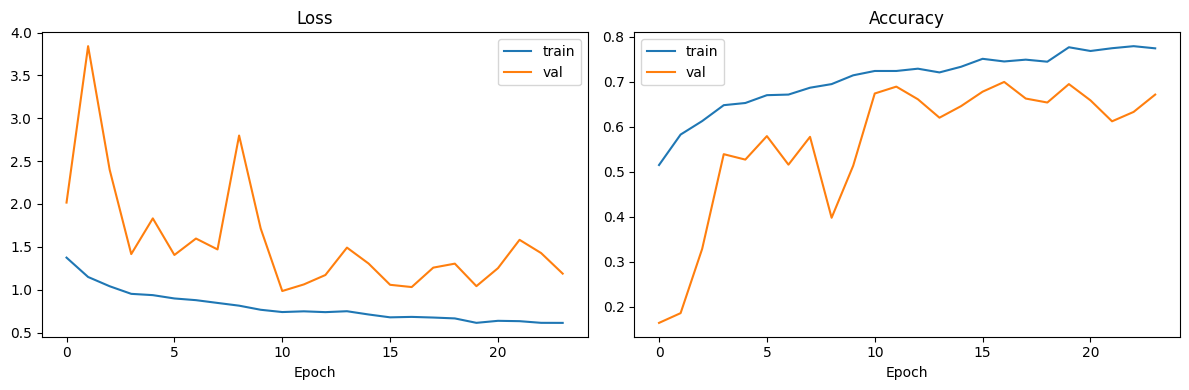

In [83]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['loss'], label='train')
axes[0].plot(history.history['val_loss'], label='val')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history.history['accuracy'], label='train')
axes[1].plot(history.history['val_accuracy'], label='val')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.show()

In [84]:
y_pred_cnn = np.argmax(cnn.predict(X_test_norm), axis=1)
print(classification_report(y_test, y_pred_cnn, target_names=class_names))

39/39 [==============================] - 2s 33ms/step
              precision    recall  f1-score   support

       cloud       0.76      0.84      0.80       233
        dust       0.79      0.67      0.73       202
        haze       0.73      0.59      0.65       200
        land       0.73      0.72      0.73       205
     seaside       0.59      0.99      0.74       202
       smoke       0.61      0.33      0.43       203

    accuracy                           0.69      1245
   macro avg       0.70      0.69      0.68      1245
weighted avg       0.70      0.69      0.68      1245



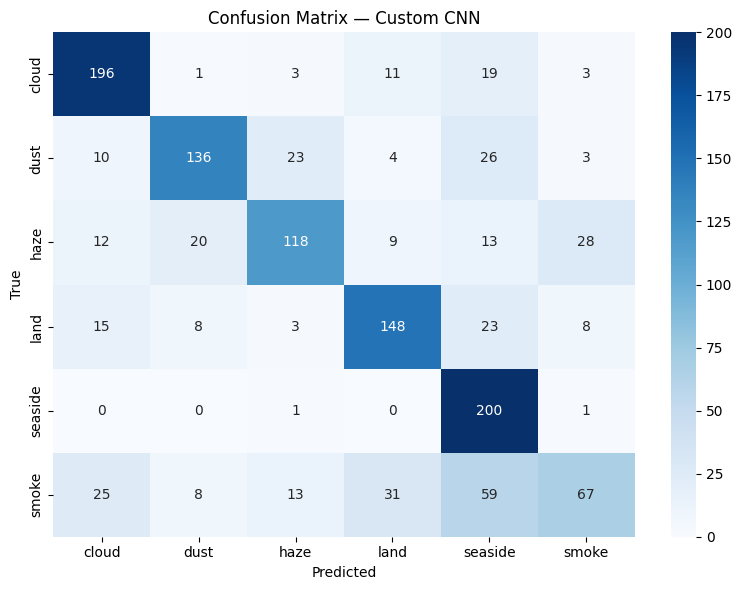

In [85]:
cm = confusion_matrix(y_test, y_pred_cnn)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title('Confusion Matrix — Custom CNN')
plt.tight_layout()
plt.show()

In [86]:
def gradcam(model, img, last_conv_name):
    grad_model = tf.keras.Model(
        inputs=model.inputs,
        outputs=[model.get_layer(last_conv_name).output, model.output]
    )
    with tf.GradientTape() as tape:
        conv_out, preds = grad_model(img[np.newaxis])
        pred_class = tf.argmax(preds[0])
        loss = preds[:, pred_class]
    grads = tape.gradient(loss, conv_out)
    pooled = tf.reduce_mean(grads, axis=(0, 1, 2))
    heatmap = tf.maximum(conv_out[0] @ pooled[..., tf.newaxis], 0)
    heatmap = tf.squeeze(heatmap)
    heatmap = heatmap / (tf.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy(), int(pred_class)

def overlay_heatmap(img, heatmap, alpha=0.4):
    heatmap_up = np.array(Image.fromarray(np.uint8(255 * heatmap)).resize((224, 224), Image.BILINEAR))
    coloured = plt.cm.jet(heatmap_up / 255.0)[:, :, :3]
    return np.clip((1 - alpha) * img + alpha * coloured, 0, 1)

last_conv = [l.name for l in cnn.layers if isinstance(l, tf.keras.layers.Conv2D)][-1]
print(f"Grad-CAM target layer: {last_conv}")

Grad-CAM target layer: conv2d_17


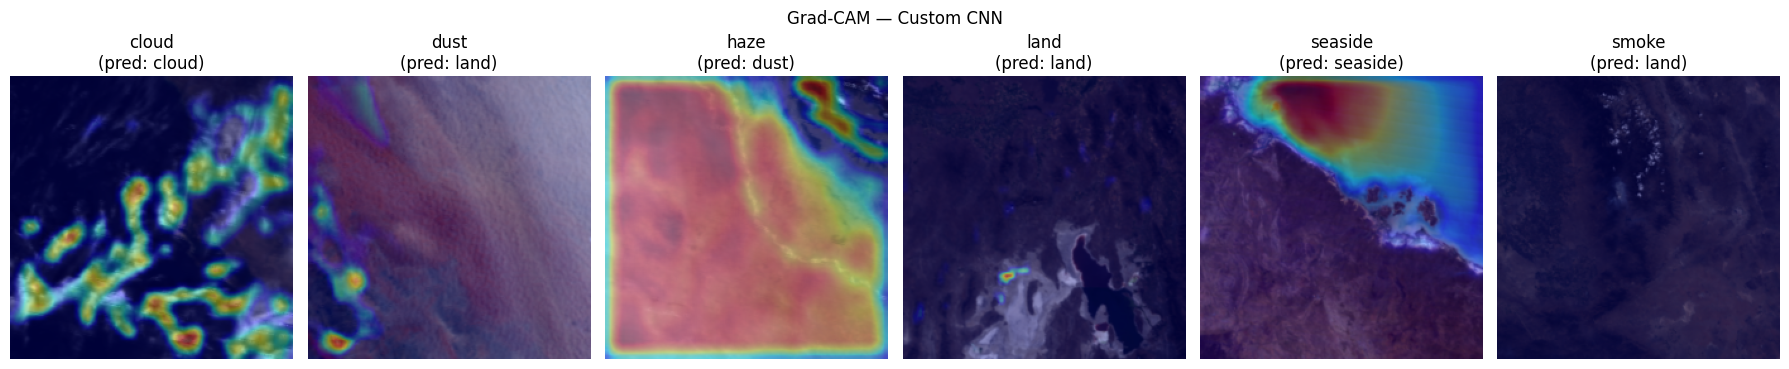

In [87]:
fig, axes = plt.subplots(1, len(class_names), figsize=(18, 4))
for ax, class_name in zip(axes, class_names):
    class_idx = class_names.index(class_name)
    idx = np.where(y_test == class_idx)[0][0]
    img = X_test_norm[idx]
    heatmap, pred = gradcam(cnn, img, last_conv)
    overlay = overlay_heatmap(img, heatmap)
    ax.imshow(overlay)
    ax.set_title(f"{class_name}\n(pred: {class_names[pred]})")
    ax.axis('off')

plt.suptitle("Grad-CAM — Custom CNN")
plt.tight_layout()
plt.show()

In [88]:
cnn.save('cnn_model.h5')
print(f"Model saved to cnn_model.h5")

Model saved to cnn_model.h5


### ResNet50 Transfer Learning

In [33]:
gpus = tf.config.list_physical_devices('GPU')
print(f"GPUs available: {len(gpus)}")
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)
    print(f"  {gpu.name} — memory growth enabled")

if not gpus:
    print("No GPU found — training will run on CPU")
else:
    with tf.device('/GPU:0'):
        a = tf.random.normal((1000, 1000))
        b = tf.random.normal((1000, 1000))
        c = tf.matmul(a, b)
    print(f"\nCompute test passed — result on: {c.device}")

GPUs available: 1
  /physical_device:GPU:0 — memory growth enabled

Compute test passed — result on: /job:localhost/replica:0/task:0/device:GPU:0


In [34]:
def build_resnet50():
    base = ResNet50(weights="imagenet", include_top=False, input_shape=(224, 224, 3))
    x = tf.keras.layers.GlobalAveragePooling2D()(base.output)
    x = tf.keras.layers.Dense(256)(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation("relu")(x)
    x = tf.keras.layers.Dropout(0.3)(x)
    out = tf.keras.layers.Dense(6, activation="softmax")(x)
    return tf.keras.Model(inputs=base.input, outputs=out), base

model_rn, base_rn = build_resnet50()
print(f"Total layers : {len(model_rn.layers)}")
print(f"Total params : {model_rn.count_params():,}")

Total layers : 181
Total params : 24,114,822


In [46]:
def augment_imagenet(x, y):
    x = tf.image.random_flip_left_right(x)
    k = tf.random.uniform(shape=[], minval=0, maxval=4, dtype=tf.int32)
    x = tf.image.rot90(x, k)
    x = tf.image.random_brightness(x, max_delta=0.5)
    x = x + tf.random.normal(shape=tf.shape(x), mean=0.0, stddev=10.0/255.0)
    return x, y

with tf.device('/CPU:0'):
    train_ds_rn = (tf.data.Dataset.from_tensor_slices((X_train_imagenet, y_train))
                   .shuffle(len(X_train_imagenet), seed=42)
                   .batch(32)
                   .map(augment_imagenet, num_parallel_calls=tf.data.AUTOTUNE)
                   .prefetch(tf.data.AUTOTUNE))

    val_ds_rn = (tf.data.Dataset.from_tensor_slices((X_val_imagenet, y_val))
                 .batch(32)
                 .prefetch(tf.data.AUTOTUNE))

for layer in base_rn.layers:
    layer.trainable = False

model_rn.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

cb_phase1 = [tf.keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=15, restore_best_weights=True, verbose=1
)]

t_phase1 = time.time()
hist1 = model_rn.fit(
    train_ds_rn,
    validation_data=val_ds_rn,
    epochs=150,
    callbacks=cb_phase1,
    verbose=1
)
phase1_time = time.time() - t_phase1
print(f"\nPhase 1 done in {phase1_time:.0f}s")

Epoch 1/150
117/117 [==============================] - 14s 94ms/step - loss: 1.3292 - accuracy: 0.4902 - val_loss: 1.5708 - val_accuracy: 0.4048
Epoch 2/150
117/117 [==============================] - 9s 76ms/step - loss: 1.1427 - accuracy: 0.5620 - val_loss: 1.7211 - val_accuracy: 0.4337
Epoch 3/150
117/117 [==============================] - 9s 76ms/step - loss: 1.0841 - accuracy: 0.5845 - val_loss: 1.3403 - val_accuracy: 0.4731
Epoch 4/150
117/117 [==============================] - 10s 77ms/step - loss: 1.0277 - accuracy: 0.6137 - val_loss: 1.2470 - val_accuracy: 0.5213
Epoch 5/150
117/117 [==============================] - 9s 76ms/step - loss: 1.0199 - accuracy: 0.6185 - val_loss: 1.1810 - val_accuracy: 0.5614
Epoch 6/150
117/117 [==============================] - 9s 75ms/step - loss: 0.9833 - accuracy: 0.6297 - val_loss: 1.0025 - val_accuracy: 0.6297
Epoch 7/150
117/117 [==============================] - 9s 74ms/step - loss: 0.9593 - accuracy: 0.6450 - val_loss: 1.3946 - val_accurac

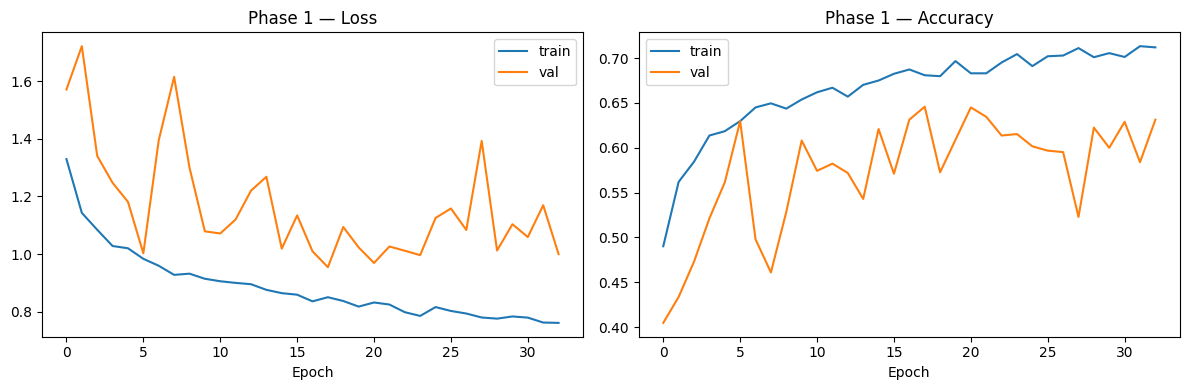

In [47]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(hist1.history["loss"], label="train")
ax1.plot(hist1.history["val_loss"], label="val")
ax1.set_title("Phase 1 — Loss")
ax1.set_xlabel("Epoch")
ax1.legend()

ax2.plot(hist1.history["accuracy"], label="train")
ax2.plot(hist1.history["val_accuracy"], label="val")
ax2.set_title("Phase 1 — Accuracy")
ax2.set_xlabel("Epoch")
ax2.legend()

plt.tight_layout()
plt.show()

In [48]:
for layer in base_rn.layers:
    layer.trainable = False
for layer in base_rn.layers[-30:]:
    layer.trainable = True

model_rn.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

cb_phase2 = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=15, restore_best_weights=True, verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=3, min_lr=1e-7, verbose=1
    )
]

t_phase2 = time.time()
hist2 = model_rn.fit(
    train_ds_rn,
    validation_data=val_ds_rn,
    epochs=150,
    callbacks=cb_phase2,
    verbose=1
)
phase2_time = time.time() - t_phase2
print(f"\nPhase 2 done in {phase2_time:.0f}s")

Epoch 1/150
117/117 [==============================] - 14s 95ms/step - loss: 1.3870 - accuracy: 0.5133 - val_loss: 1.6755 - val_accuracy: 0.4321 - lr: 1.0000e-05
Epoch 2/150
117/117 [==============================] - 10s 84ms/step - loss: 1.0780 - accuracy: 0.5960 - val_loss: 1.2578 - val_accuracy: 0.5205 - lr: 1.0000e-05
Epoch 3/150
117/117 [==============================] - 10s 84ms/step - loss: 0.9396 - accuracy: 0.6463 - val_loss: 1.0653 - val_accuracy: 0.6048 - lr: 1.0000e-05
Epoch 4/150
117/117 [==============================] - 10s 84ms/step - loss: 0.9014 - accuracy: 0.6627 - val_loss: 0.9527 - val_accuracy: 0.6394 - lr: 1.0000e-05
Epoch 5/150
117/117 [==============================] - 11s 87ms/step - loss: 0.8337 - accuracy: 0.7015 - val_loss: 0.8982 - val_accuracy: 0.6755 - lr: 1.0000e-05
Epoch 6/150
117/117 [==============================] - 10s 83ms/step - loss: 0.8022 - accuracy: 0.7098 - val_loss: 0.9221 - val_accuracy: 0.6755 - lr: 1.0000e-05
Epoch 7/150
117/117 [=======

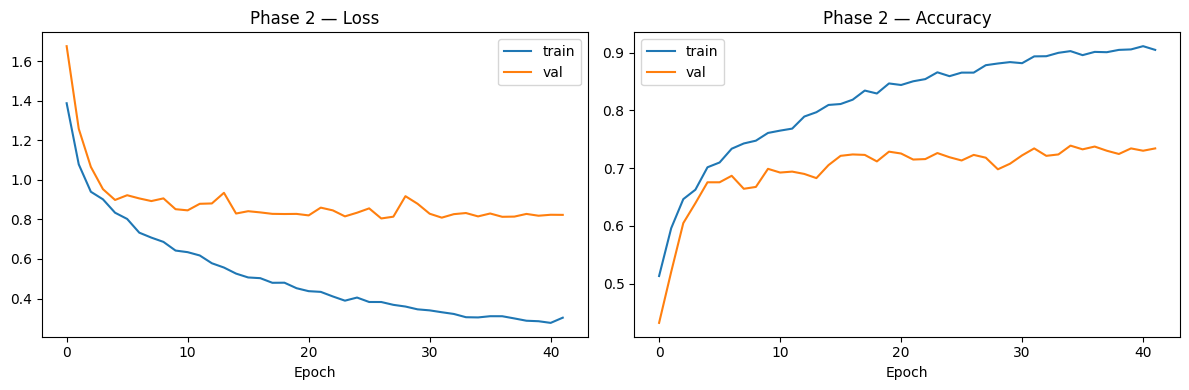

In [49]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(hist2.history["loss"], label="train")
ax1.plot(hist2.history["val_loss"], label="val")
ax1.set_title("Phase 2 — Loss")
ax1.set_xlabel("Epoch")
ax1.legend()

ax2.plot(hist2.history["accuracy"], label="train")
ax2.plot(hist2.history["val_accuracy"], label="val")
ax2.set_title("Phase 2 — Accuracy")
ax2.set_xlabel("Epoch")
ax2.legend()

plt.tight_layout()
plt.show()

In [50]:
y_pred_rn = model_rn.predict(X_test_imagenet, batch_size=32).argmax(axis=1)
print(classification_report(y_test, y_pred_rn, target_names=class_names))

39/39 [==============================] - 3s 53ms/step
              precision    recall  f1-score   support

       cloud       0.80      0.78      0.79       233
        dust       0.75      0.70      0.73       202
        haze       0.67      0.68      0.68       200
        land       0.72      0.82      0.77       205
     seaside       0.92      0.89      0.90       202
       smoke       0.61      0.59      0.60       203

    accuracy                           0.74      1245
   macro avg       0.74      0.74      0.74      1245
weighted avg       0.75      0.74      0.74      1245



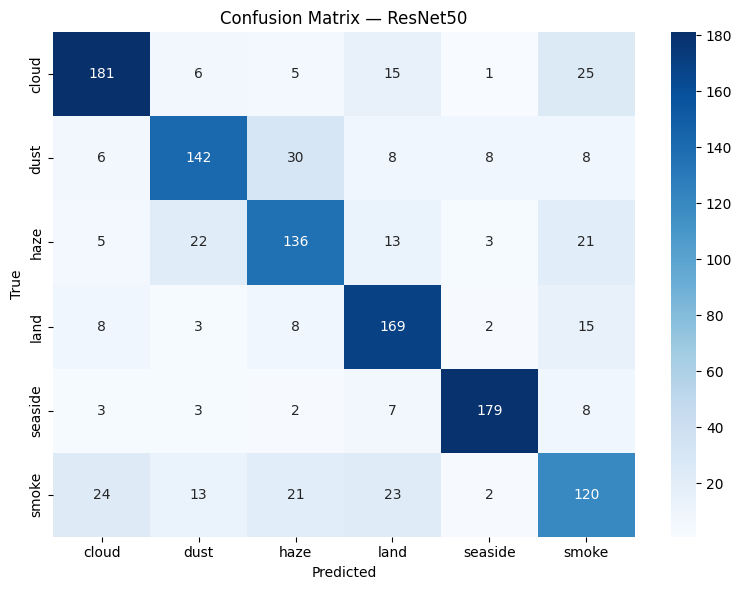

In [51]:
cm = confusion_matrix(y_test, y_pred_rn)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title('Confusion Matrix — ResNet50')
plt.tight_layout()
plt.show()

In [52]:
model_rn.save("resnet50_finetuned.h5")
print("Model saved: resnet50_finetuned.h5")
print(f"\nTraining summary:")
print(f"  Phase 1 : {phase1_time:.0f}s  ({len(hist1.epoch)} epochs)")
print(f"  Phase 2 : {phase2_time:.0f}s  ({len(hist2.epoch)} epochs)")
print(f"  Total   : {phase1_time + phase2_time:.0f}s")

Model saved: resnet50_finetuned.h5

Training summary:
  Phase 1 : 312s  (33 epochs)
  Phase 2 : 433s  (42 epochs)
  Total   : 745s


### SVM

In [35]:
X_train_flat = X_train_norm.reshape(len(X_train_norm), -1)
X_test_flat  = X_test_norm.reshape(len(X_test_norm), -1)

print(f"Flattened shape : {X_train_flat.shape}")

_pca = PCA(n_components=200, random_state=42).fit(X_train_flat)
print(f"Variance explained by 200 components: {_pca.explained_variance_ratio_.sum():.1%}")
del _pca

Flattened shape : (3735, 150528)
Variance explained by 200 components: 94.2%


In [36]:
pipe_svm = Pipeline([
    ('pca',    PCA(n_components=200, random_state=42)),
    ('scaler', StandardScaler()),
    ('svm',    SVC(decision_function_shape='ovr', random_state=42))
])

param_grid = [{'svm__kernel': ['rbf'],
               'svm__C':     [0.1, 1, 10, 100],
               'svm__gamma': ['scale', 'auto']}]

gs_svm = GridSearchCV(pipe_svm, param_grid, cv=5, scoring='accuracy',
                      n_jobs=1, verbose=2)

t_svm = time.time()
gs_svm.fit(X_train_flat, y_train)
svm_time = time.time() - t_svm

print(f"Best params   : {gs_svm.best_params_}")
print(f"Best CV acc   : {gs_svm.best_score_:.4f}")
print(f"Training time : {svm_time:.0f}s  ({svm_time/60:.1f} min)")

Fitting 5 folds for each of 8 candidates, totalling 40 fits
[CV] END ......svm__C=0.1, svm__gamma=scale, svm__kernel=rbf; total time=  15.0s
[CV] END ......svm__C=0.1, svm__gamma=scale, svm__kernel=rbf; total time=  15.0s
[CV] END ......svm__C=0.1, svm__gamma=scale, svm__kernel=rbf; total time=  15.7s
[CV] END ......svm__C=0.1, svm__gamma=scale, svm__kernel=rbf; total time=  15.3s
[CV] END ......svm__C=0.1, svm__gamma=scale, svm__kernel=rbf; total time=  15.0s
[CV] END .......svm__C=0.1, svm__gamma=auto, svm__kernel=rbf; total time=  15.4s
[CV] END .......svm__C=0.1, svm__gamma=auto, svm__kernel=rbf; total time=  15.3s
[CV] END .......svm__C=0.1, svm__gamma=auto, svm__kernel=rbf; total time=  15.3s
[CV] END .......svm__C=0.1, svm__gamma=auto, svm__kernel=rbf; total time=  15.2s
[CV] END .......svm__C=0.1, svm__gamma=auto, svm__kernel=rbf; total time=  15.1s
[CV] END ........svm__C=1, svm__gamma=scale, svm__kernel=rbf; total time=  15.0s
[CV] END ........svm__C=1, svm__gamma=scale, svm_

In [37]:
y_pred_svm = svm_model.predict(X_test_flat)
print(classification_report(y_test, y_pred_svm, target_names=class_names))


              precision    recall  f1-score   support

       cloud       0.52      0.58      0.54       233
        dust       0.50      0.49      0.49       202
        haze       0.56      0.59      0.58       200
        land       0.49      0.43      0.46       205
     seaside       0.71      0.48      0.57       202
       smoke       0.43      0.57      0.49       203

    accuracy                           0.52      1245
   macro avg       0.54      0.52      0.52      1245
weighted avg       0.54      0.52      0.52      1245



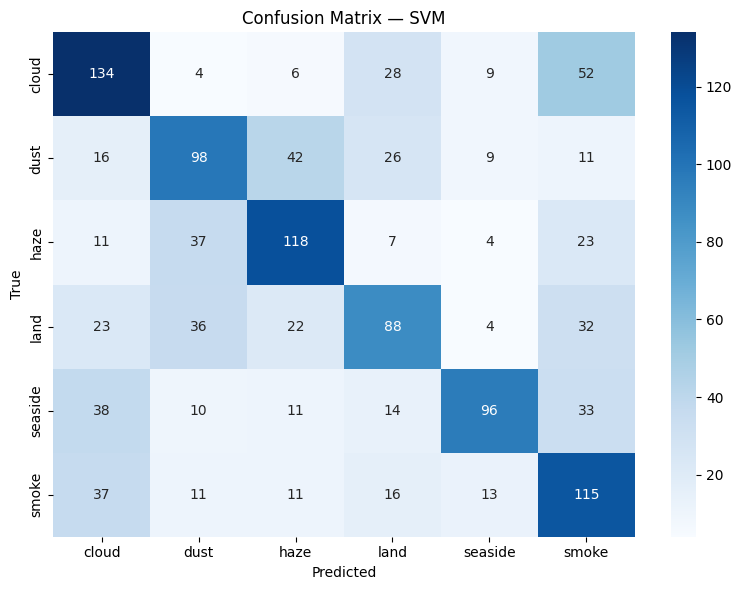

In [38]:
cm = confusion_matrix(y_test, y_pred_svm)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title('Confusion Matrix — SVM')
plt.tight_layout()
plt.show()

In [48]:
svm_model = joblib.load('svm_model.pkl')
print('Model loaded: svm_model.pkl')
print('Training time : 603s  (10.1 min)')
print('Best params   : {svm__C: 1, svm__gamma: scale, svm__kernel: rbf}')
print('Best CV acc   : 0.4937')


Model loaded: svm_model.pkl
Training time : 603s  (10.1 min)
Best params   : {svm__C: 1, svm__gamma: scale, svm__kernel: rbf}
Best CV acc   : 0.4937
